<a href="https://colab.research.google.com/github/yejxjj/AI_lab/blob/main/hw_regressionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import kagglehub
import glob
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # 메트릭스 계산용

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


In [3]:

print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("andonians/random-linear-regression")

# 폴더에서 CSV 파일 찾기
csv_files = glob.glob(os.path.join(path, "*.csv"))
target_file = next((f for f in csv_files if 'train' in f.lower()), csv_files[0])

# 데이터 읽기
df = pd.read_csv(target_file)
df = df.dropna() # 빈 데이터 제거

# Feature(X)와 Target(y) 지정
X = df[['x']].values  # 입력
y = df['y'].values    # 정답
# ---------------------------------------------------------

100%|██████████| 7.63k/7.63k [00:00<00:00, 17.1MB/s]

Extracting files...


In [4]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Normalize features using StandardScaler
# This helps neural networks train faster and more stably
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler() # y를 위한 스케일러 별도 생성
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)) # y는 1차원이므로 reshape
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

print("\n✓ Data normalized (mean=0, std=1) including Target values.")

Training set size: 559 samples
Test set size: 140 samples

✓ Data normalized (mean=0, std=1) including Target values.


In [5]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train_scaled).to(device) # y도 스케일링된 텐서 사용
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test_scaled).to(device) # y도 스케일링된 텐서 사용

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 64
Number of training batches: 9
Number of test batches: 3


In [6]:
class RegressionModel(nn.Module):
    def __init__(self, input_size): # Hidden Size를 내부에서 정의하도록 변경
        super(RegressionModel, self).__init__()

        # 더 깊고 넓은 네트워크 구성 (배치 정규화 추가)
        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 128),  # 첫 번째 은닉층
            nn.BatchNorm1d(128),         # 배치 정규화 (학습 안정화, 속도 향상)
            nn.ReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),          # 두 번째 은닉층
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.layer3 = nn.Sequential(
            nn.Linear(64, 32),           # 세 번째 은닉층
            nn.ReLU()
        )
        self.output_layer = nn.Linear(32, 1) # 최종 출력층

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output_layer(x)
        return x

# 모델 초기화 부분도 input_size만 전달하도록 변경
input_size = X_train_scaled.shape[1]  # Number of features
model = RegressionModel(input_size).to(device) # 모델에 input_size만 전달

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (layer1): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cuda


In [7]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam (초기 학습률을 조금 높여서 시작)
learning_rate = 0.005 # 기존 0.001에서 0.005로 상향 조정
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ★ 학습률 스케줄러 추가 (정확도 향상 비법 중 하나)
# 검증 손실(Test Loss)이 20번의 epoch 동안 개선되지 않으면 학습률을 0.5배로 줄입니다.
# 이렇게 하면 최적점 근처에서 더 세밀하게 탐색하여 더 낮은 손실에 도달할 수 있습니다.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20
)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam (initial lr={learning_rate})")
print(f"Scheduler: ReduceLROnPlateau (patience=20, factor=0.5)")

Loss function: MSELoss()
Optimizer: Adam (initial lr=0.005)
Scheduler: ReduceLROnPlateau (patience=20, factor=0.5)


In [8]:
# Training parameters
num_epochs = 500 # 기존 100에서 500으로 대폭 증가시켜 충분히 학습하도록 함

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training with increased epochs and scheduler...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation phase
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # ★ 스케줄러 업데이트: 테스트 손실을 기준으로 학습률 조정
    scheduler.step(avg_test_loss)

    # Print progress every 50 epochs (로그 출력 주기 변경)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.6f} | " # 소수점 자리수 늘림
              f"Test Loss: {avg_test_loss:.6f} | "
              f"Current LR: {optimizer.param_groups[0]['lr']:.6f}") # 현재 학습률도 출력

Starting training with increased epochs and scheduler...
------------------------------------------------------------
Epoch [50/500] | Train Loss: 0.027176 | Test Loss: 0.010257 | Current LR: 0.005000
Epoch [100/500] | Train Loss: 0.037757 | Test Loss: 0.009936 | Current LR: 0.001250
Epoch [150/500] | Train Loss: 0.032678 | Test Loss: 0.009292 | Current LR: 0.000156
Epoch [200/500] | Train Loss: 0.024374 | Test Loss: 0.009248 | Current LR: 0.000039
Epoch [250/500] | Train Loss: 0.024871 | Test Loss: 0.009592 | Current LR: 0.000005
Epoch [300/500] | Train Loss: 0.017240 | Test Loss: 0.009390 | Current LR: 0.000001
Epoch [350/500] | Train Loss: 0.022521 | Test Loss: 0.009355 | Current LR: 0.000000
Epoch [400/500] | Train Loss: 0.023353 | Test Loss: 0.009309 | Current LR: 0.000000
Epoch [450/500] | Train Loss: 0.029247 | Test Loss: 0.009164 | Current LR: 0.000000
Epoch [500/500] | Train Loss: 0.019822 | Test Loss: 0.009207 | Current LR: 0.000000


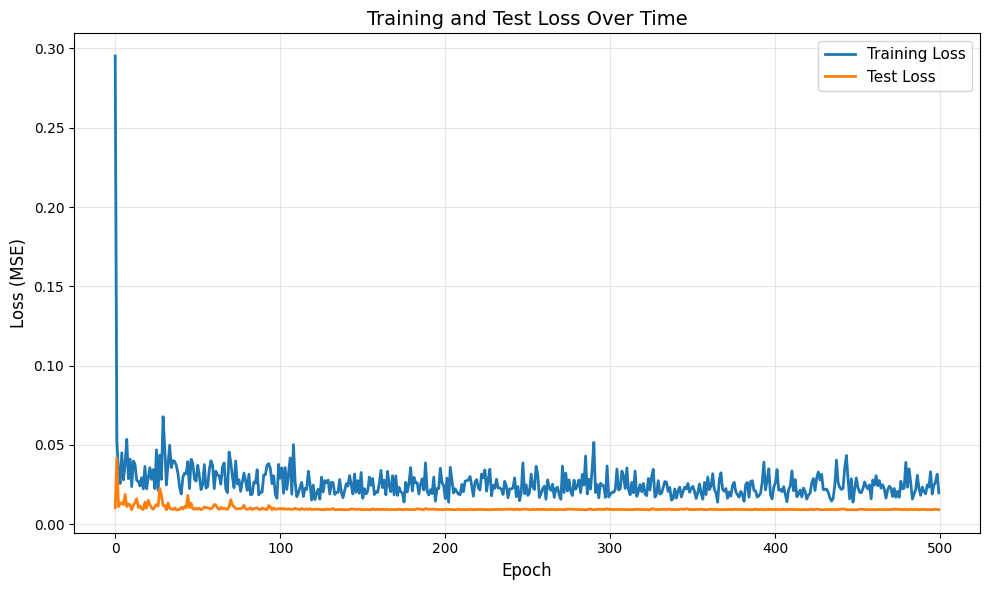

Final Training Loss: 0.0198
Final Test Loss: 0.0092


In [9]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")


Model Performance on Test Set (Original Scale):
Mean Squared Error (MSE):       8.1542
Root Mean Squared Error (RMSE): 2.8556
Mean Absolute Error (MAE):      2.2997
R² Score:                       0.9906

Interpretation:
On average, predictions are off by approximately 2.30
Model explains 99.06% of the variance in the target values.


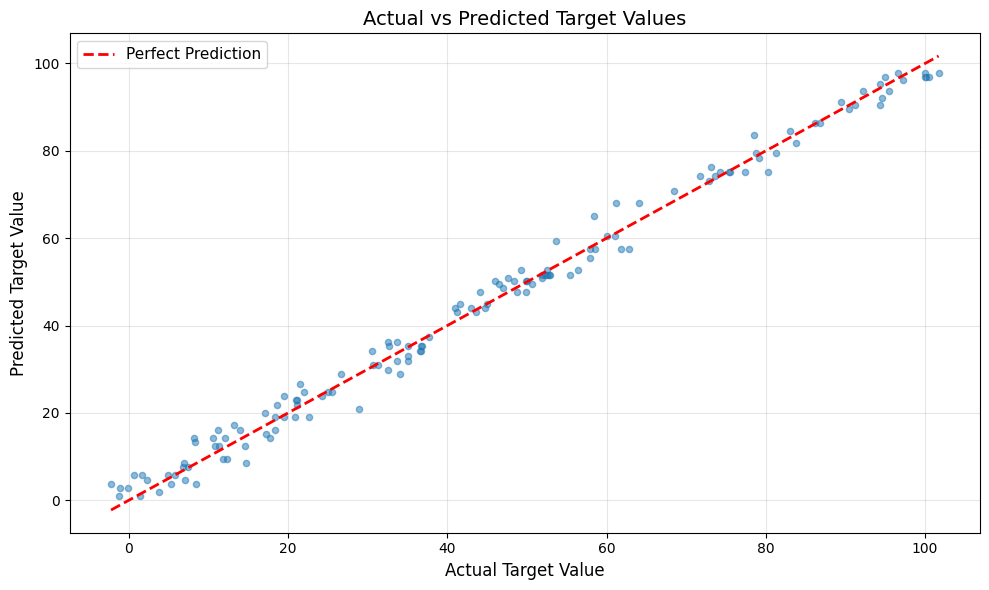


Sample Predictions (first 10 entries):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
       96.62 |        97.78 |        -1.16
       94.30 |        95.33 |        -1.03
       14.56 |        12.37 |         2.19
       86.82 |        86.34 |         0.48
       94.37 |        90.44 |         3.93
      100.02 |        97.78 |         2.23
       58.37 |        64.97 |        -6.60
       25.04 |        24.78 |         0.26
       36.60 |        34.09 |         2.50
       21.11 |        21.88 |        -0.77


In [10]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred_scaled = model(X_test_device).cpu().numpy() # 스케일링된 예측 값

    # ★ y 값을 원래 스케일로 복구합니다.
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = y_test.reshape(-1, 1) # 원래 y_test 값 사용 (reshape로 형태 맞춤)

# Calculate metrics
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # 맨 위에서 import 했으므로 주석 처리

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("\nModel Performance on Test Set (Original Scale):") # 제목 변경
print("=" * 50)
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"R² Score:                       {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
# 이 데이터셋은 단위가 명확하지 않으므로, 일반적인 해석으로 변경
print(f"On average, predictions are off by approximately {mae:.2f}")
print(f"Model explains {r2*100:.2f}% of the variance in the target values.")


# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Target Value', fontsize=12)    # 라벨 변경
plt.ylabel('Predicted Target Value', fontsize=12) # 라벨 변경
plt.title('Actual vs Predicted Target Values', fontsize=14) # 제목 변경
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 entries):") # 제목 변경
print("-" * 60)
# 출력 형식도 '$' 대신 그냥 숫자 값으로 변경 (이 데이터셋에선 화폐 단위가 아님)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0]
    predicted = y_pred[i][0]
    diff = actual - predicted
    print(f"{actual:>12.2f} | {predicted:>12.2f} | {diff:>12.2f}") # 소수점 2자리까지 출력

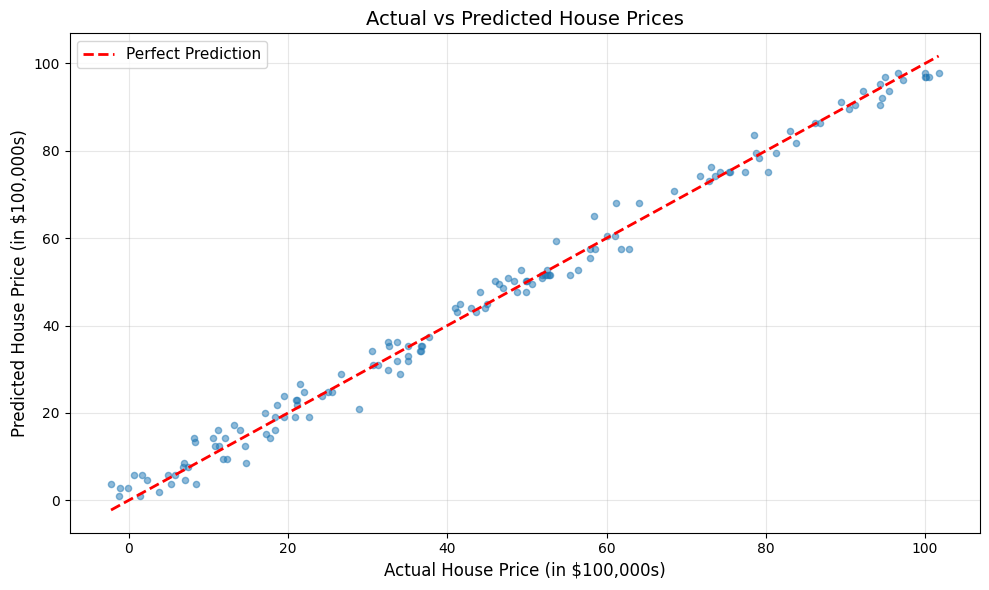


Sample Predictions (first 10 houses):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
$ 9,662,328 | $ 9,778,252 | $  -115,924
$ 9,429,633 | $ 9,533,035 | $  -103,402
$ 1,455,896 | $ 1,236,591 | $   219,305
$ 8,682,132 | $ 8,634,437 | $    47,695
$ 9,436,779 | $ 9,043,606 | $   393,173
$10,001,580 | $ 9,778,252 | $   223,328
$ 5,837,266 | $ 6,497,487 | $  -660,221
$ 2,504,169 | $ 2,478,414 | $    25,755
$ 3,659,623 | $ 3,409,456 | $   250,167
$ 2,110,795 | $ 2,188,025 | $   -77,231


In [11]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Price (in $100,000s)', fontsize=12)
plt.ylabel('Predicted House Price (in $100,000s)', fontsize=12)
plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 houses):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0] * 100000
    predicted = y_pred[i][0] * 100000
    diff = actual - predicted
    print(f"${actual:>10,.0f} | ${predicted:>10,.0f} | ${diff:>10,.0f}")

In [12]:
# Save model
torch.save(model.state_dict(), 'best_regression_model.pth') # 파일 이름 변경
print("✓ Model saved to 'best_regression_model.pth'")

# 로드 안내 메시지도 파일 이름에 맞게 변경
print("\nTo load this model later, use:")
print("  model = RegressionModel(input_size)")
print("  model.load_state_dict(torch.load('best_regression_model.pth'))")
print("  model.to(device)")
print("  model.eval()")

✓ Model saved to 'best_regression_model.pth'

To load this model later, use:
  model = RegressionModel(input_size)
  model.load_state_dict(torch.load('best_regression_model.pth'))
  model.to(device)
  model.eval()
